# RFM и ABC-XYZ Анализ

## Цель
Сегментировать клиентов по ценности (RFM) и товары по вкладу в выручку и стабильности спроса (ABC-XYZ) для таргетирования маркетинговых активностей и оптимизации запасов.

## Аналитические вопросы
1. Какие сегменты клиентов приносят основную выручку, а какие находятся в зоне риска оттока?
2. Какие товары (категории) формируют 80% выручки (группа A)?
3. Насколько стабилен спрос на товары группы A (анализ XYZ)?

## Ожидаемый результат
- Датафрейм с RFM-сегментами клиентов.
- Датафрейм с ABC-XYZ матрицей товаров.
- Визуализации распределения сегментов.
- Сохраненный файл `rfm_abc_segments.csv` для BI и ML.

##Импорт и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# Загрузка очищенных данных
orders = pd.read_csv('../data/processed/orders_clean.csv')
products = pd.read_csv('../data/processed/products_clean.csv')
customers = pd.read_csv('../data/processed/customers_clean.csv')

# Приведение дат (на всякий случай, если не сохранились как datetime)
orders['order_date'] = pd.to_datetime(orders['order_date'])

print("Данные загружены. Shape orders:", orders.shape)

Данные загружены. Shape orders: (25000, 29)


## 1. RFM Анализ клиентов
- **Recency (R)**: Дней с последней покупки (чем меньше, тем лучше).
- **Frequency (F)**: Количество заказов (чем больше, тем лучше).
- **Monetary (M)**: Общая сумма покупок (чем больше, тем лучше).

In [2]:
# Дата среза для расчета Recency (максимальная дата в датасете + 1 день)
snapshot_date = orders['order_date'].max() + pd.Timedelta(days=1)

# Агрегация по клиентам
rfm = orders.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'count',                                     # Frequency
    'total_amount_usd': 'sum'                                # Monetary
}).rename(columns={
    'order_date': 'recency',
    'order_id': 'frequency',
    'total_amount_usd': 'monetary'
}).reset_index()

# Проверка
print("RFM статистика:")
display(rfm.describe())

RFM статистика:


,recency,frequency,monetary
count,7663.000000,7663.000000,7663.000000
mean,623.121362,3.262430,409.292008
std,531.809197,1.670653,335.513360
min,1.000000,1.000000,8.610000
25%,199.000000,2.000000,170.840000
50%,470.000000,3.000000,322.370000
75%,917.000000,4.000000,549.860000
max,2281.000000,12.000000,3602.810000


##RFM Скоринг и Сегментация

/var/folders/gw/cyj6vpkn23s80_ny89rzfjwc0000gn/T/ipykernel_2426/2791119178.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')


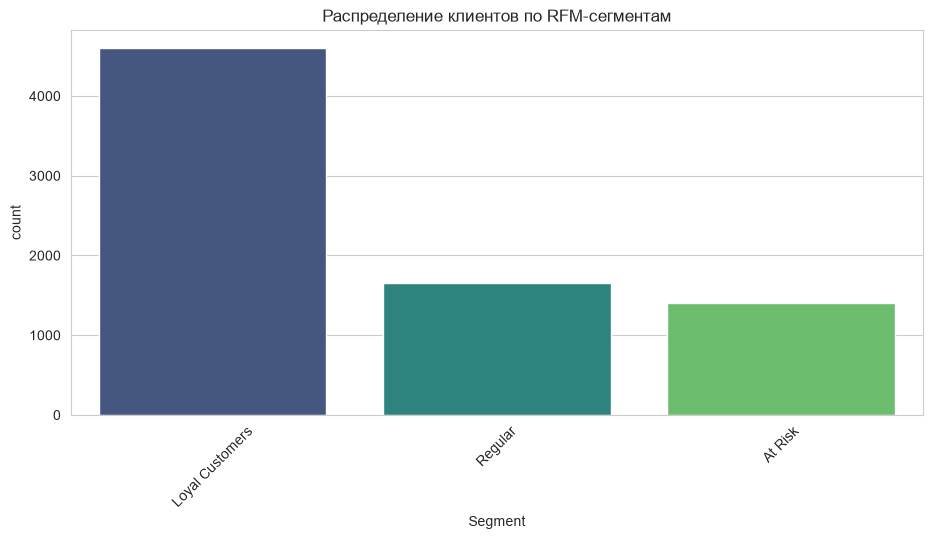


Доля выручки по сегментам:
Segment
Loyal Customers    69.2%
At Risk            24.0%
Regular             6.8%
Name: monetary, dtype: str


In [3]:
#Примечание: используем duplicates='drop', так как в квантилях иногда бывают одинаковые границы.
# Функция для безопасного квантильного разбиения
def score_qcut(series, ascending=True):
    try:
        if ascending:
            return pd.qcut(series, q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
        else: # Для Recency: меньше дней = выше оценка (5)
            return pd.qcut(series, q=5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)
    except ValueError:
        # Если уникальных значений меньше 5, присваиваем средний балл 3
        return pd.Series(3, index=series.index)

rfm['R_score'] = score_qcut(rfm['recency'], ascending=False)
rfm['F_score'] = score_qcut(rfm['frequency'], ascending=True)
rfm['M_score'] = score_qcut(rfm['monetary'], ascending=True)

# Общий RFM Score (сумма баллов от 3 до 15)
rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Простая сегментация на основе правил
def rfm_segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'New Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Lost'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

# Визуализация распределения
plt.figure(figsize=(11, 5))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Распределение клиентов по RFM-сегментам')
plt.xticks(rotation=45)
plt.show()

# Доля выручки по сегментам
segment_revenue = rfm.groupby('Segment')['monetary'].sum().sort_values(ascending=False)
print("\nДоля выручки по сегментам:")
print((segment_revenue / segment_revenue.sum() * 100).round(1).astype(str) + '%')

## 2. ABC Анализ товаров
- **A**: Топ-товары, формирующие ~80% выручки.
- **B**: Товары, формирующие следующие ~15% выручки.
- **C**: Товары, формирующие оставшиеся ~5% выручки.

In [4]:
# Агрегация выручки по товарам
product_revenue = orders.groupby('product_name')['total_amount_usd'].sum().reset_index()
product_revenue = product_revenue.sort_values('total_amount_usd', ascending=False).reset_index(drop=True)

# Накопительный итог и процент
product_revenue['cumulative_revenue'] = product_revenue['total_amount_usd'].cumsum()
total_revenue = product_revenue['total_amount_usd'].sum()
product_revenue['cumulative_pct'] = product_revenue['cumulative_revenue'] / total_revenue

# Присвоение категорий ABC
conditions = [
    product_revenue['cumulative_pct'] <= 0.80,
    product_revenue['cumulative_pct'] <= 0.95
]
choices = ['A', 'B']
product_revenue['ABC_Group'] = np.select(conditions, choices, default='C')

print("Распределение товаров по ABC:")
display(product_revenue['ABC_Group'].value_counts())

# Проверка шага 23 (корректность расчетов)
print(f"\nПроверка: Сумма выручки группы A = {product_revenue[product_revenue['ABC_Group']=='A']['total_amount_usd'].sum() / total_revenue * 100:.1f}% от общей")

Распределение товаров по ABC:


ABC_Group
A    62
B    49
C    29
Name: count, dtype: int64


Проверка: Сумма выручки группы A = 79.7% от общей


## 3. XYZ Анализ (Коэффициент вариации спроса)
- **X**: CV ≤ 0.1 (Стабильный спрос)
- **Y**: 0.1 < CV ≤ 0.25 (Колеблющийся спрос)
- **Z**: CV > 0.25 (Нестабильный, хаотичный спрос)

In [5]:
# Создаем таблицу продаж по месяцам для каждого товара
orders['month'] = orders['order_date'].dt.to_period('M')
monthly_product_sales = orders.groupby(['product_name', 'month'])['total_amount_usd'].sum().unstack(fill_value=0)

# Расчет среднего и стандартного отклонения
xyz_data = pd.DataFrame({
    'mean_sales': monthly_product_sales.mean(axis=1),
    'std_sales': monthly_product_sales.std(axis=1)
})

# Коэффициент вариации (CV)
# Заполняем NaN (если не было продаж) нулем, чтобы избежать ошибок деления
xyz_data['cv'] = (xyz_data['std_sales'] / xyz_data['mean_sales']).fillna(0)

# Присвоение категорий XYZ
xyz_conditions = [
    xyz_data['cv'] <= 0.10,
    xyz_data['cv'] <= 0.25
]
xyz_choices = ['X', 'Y']
xyz_data['XYZ_Group'] = np.select(xyz_conditions, xyz_choices, default='Z')

print("Распределение товаров по XYZ:")
display(xyz_data['XYZ_Group'].value_counts())

Распределение товаров по XYZ:


XYZ_Group
Z    140
Name: count, dtype: int64

##Наблюдение и интерпретация

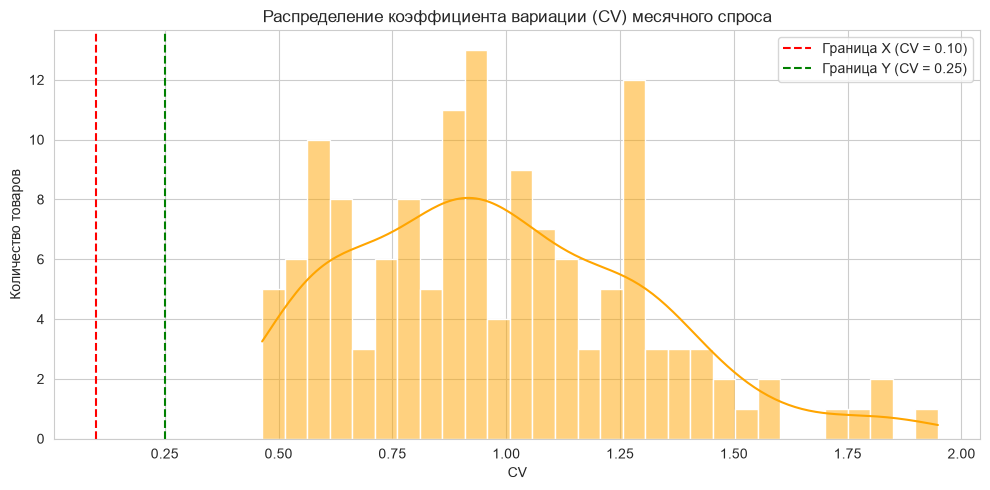

CV: min = 0.46, медиана = 0.93, max = 1.95
Доля товаров с CV > 0.25 (группа Z): 100.0%


In [6]:
# Анализ распределения CV проверка результата XYZ
plt.figure(figsize=(10, 5))
sns.histplot(xyz_data['cv'], bins=30, kde=True, color='orange')
plt.axvline(0.10, color='red', linestyle='--', label='Граница X (CV = 0.10)')
plt.axvline(0.25, color='green', linestyle='--', label='Граница Y (CV = 0.25)')
plt.title('Распределение коэффициента вариации (CV) месячного спроса')
plt.xlabel('CV')
plt.ylabel('Количество товаров')
plt.legend()
plt.tight_layout()
plt.show()

print(f"CV: min = {xyz_data['cv'].min():.2f}, медиана = {xyz_data['cv'].median():.2f}, max = {xyz_data['cv'].max():.2f}")
print(f"Доля товаров с CV > 0.25 (группа Z): {(xyz_data['cv'] > 0.25).mean() * 100:.1f}%")

1. Сегмент Loyal Customers формирует 69,2% выручки, At Risk — 24,0%, Regular — 6,8%.
   Сегменты Champions, New Customers и Lost на этом датасете пусты: правила сегментации
   не срабатывают при данном распределении R/F/M — зафиксировано как особенность, а не ошибка.
   Для Loyal нужна программа лояльности, для At Risk — реактивационные кампании.

In [7]:
# 1. Проверка RFM: сумма monetary должна совпадать с общей выручкой
rfm_monetary_sum = rfm['monetary'].sum()
orders_total = orders['total_amount_usd'].sum()
print(f"Сумма monetary в RFM: {rfm_monetary_sum:.2f}")
print(f"Сумма total_amount_usd в orders: {orders_total:.2f}")
print(f"Разница: {abs(rfm_monetary_sum - orders_total):.2f}")
print(f"Совпадение: {abs(rfm_monetary_sum - orders_total) < 1.0}")

# 2. Проверка ABC: сумма выручки группы A
abc_a_revenue = product_revenue[product_revenue['ABC_Group'] == 'A']['total_amount_usd'].sum()
print(f"\nВыручка группы A: {abc_a_revenue:.2f}")
print(f"Доля от общей: {abc_a_revenue / total_revenue * 100:.1f}%")

# 3. Проверка количества клиентов в RFM
print(f"\nКлиентов в RFM: {len(rfm)}")
print(f"Клиентов в customers: {len(customers)}")
print(f"Клиентов без заказов в периоде: {len(customers) - len(rfm)}")

Сумма monetary в RFM: 3136404.66
Сумма total_amount_usd в orders: 3136404.66
Разница: 0.00
Совпадение: True

Выручка группы A: 2500429.77
Доля от общей: 79.7%

Клиентов в RFM: 7663
Клиентов в customers: 8000
Клиентов без заказов в периоде: 337


##Объединение ABC и XYZ + Визуализация

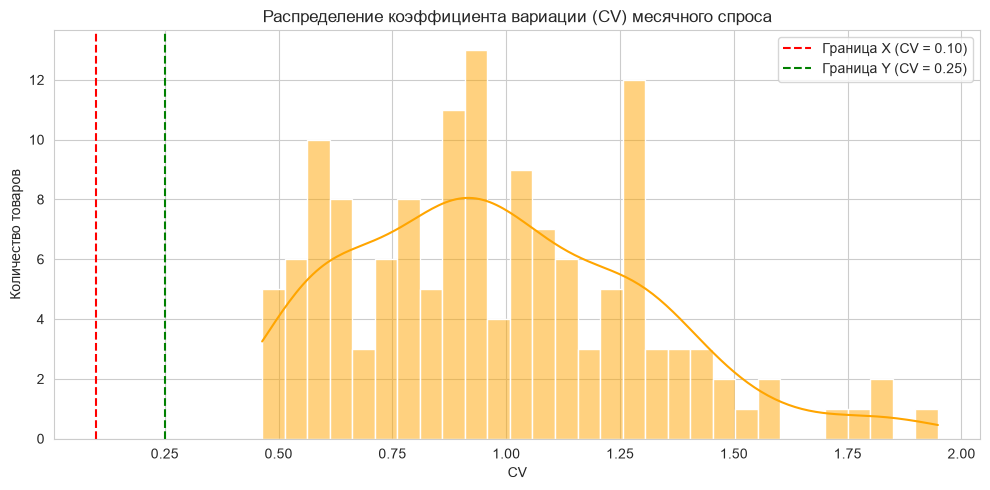

CV: min = 0.46, медиана = 0.93, max = 1.95
Доля товаров с CV > 0.25 (группа Z): 100.0%


In [8]:
# Анализ распределения CV: проверка результата XYZ
plt.figure(figsize=(10, 5))
sns.histplot(xyz_data['cv'], bins=30, kde=True, color='orange')
plt.axvline(0.10, color='red', linestyle='--', label='Граница X (CV = 0.10)')
plt.axvline(0.25, color='green', linestyle='--', label='Граница Y (CV = 0.25)')
plt.title('Распределение коэффициента вариации (CV) месячного спроса')
plt.xlabel('CV')
plt.ylabel('Количество товаров')
plt.legend()
plt.tight_layout()
plt.show()

print(f"CV: min = {xyz_data['cv'].min():.2f}, медиана = {xyz_data['cv'].median():.2f}, max = {xyz_data['cv'].max():.2f}")
print(f"Доля товаров с CV > 0.25 (группа Z): {(xyz_data['cv'] > 0.25).mean() * 100:.1f}%")

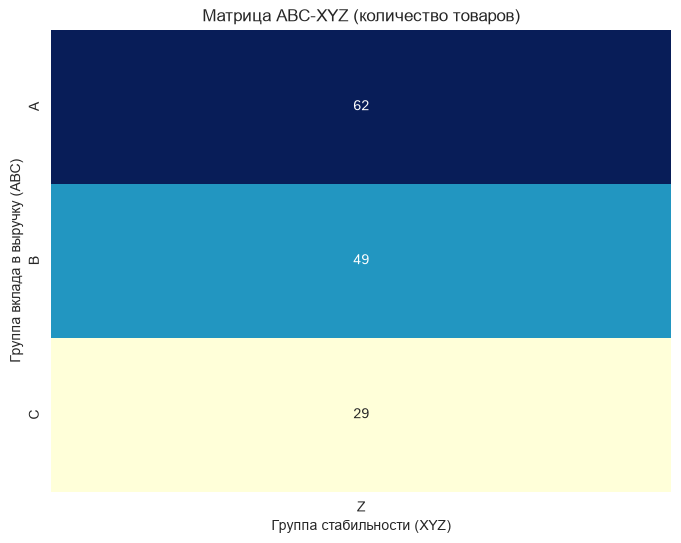

✅ ABC-XYZ анализ завершен.
Размер объединенной таблицы: (140, 4) (должно быть 140 строк)

Пример первых 5 строк:


,product_name,total_amount_usd,ABC_Group,XYZ_Group
0,Portable Charger 20000mAh,131146.55,A,Z
1,Webcam 4K,117418.25,A,Z
2,Smart Watch Series 5,116859.12,A,Z
3,USB-C Hub,115986.18,A,Z
4,Wireless Earbuds Pro,115198.45,A,Z


In [9]:
# 1. Сбрасываем индекс xyz_data, чтобы product_name стал столбцом
xyz_data_reset = xyz_data.reset_index()

# 2. Объединяем ABC и XYZ по столбцу product_name
abc_xyz = product_revenue[['product_name', 'total_amount_usd', 'ABC_Group']].merge(
    xyz_data_reset[['product_name', 'XYZ_Group']], 
    on='product_name'
)

# 3. Создаем сводную матрицу ABC-XYZ
abc_xyz_matrix = abc_xyz.groupby(['ABC_Group', 'XYZ_Group']).size().unstack(fill_value=0)

# 4. Визуализация матрицы (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(abc_xyz_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Матрица ABC-XYZ (количество товаров)')
plt.xlabel('Группа стабильности (XYZ)')
plt.ylabel('Группа вклада в выручку (ABC)')
plt.show()

# 5. Сохраняем объединенный датафрейм
abc_xyz_final = abc_xyz.reset_index(drop=True)

# Проверка результата
print("✅ ABC-XYZ анализ завершен.")
print(f"Размер объединенной таблицы: {abc_xyz.shape} (должно быть 140 строк)")
print("\nПример первых 5 строк:")
display(abc_xyz_final.head())

## Выводы и Рекомендации

### RFM
1. Сегмент **Loyal Customers** формирует 69,2% выручки, **At Risk** — 24,0%, **Regular** — 6,8%. Сегменты Champions, New Customers и Lost пусты из-за жестких границ квантилей на данном распределении.
2. Сегмент **At Risk** (высокие F и M, но низкий R) требует немедленных реактивационных кампаний.

### ABC
- Группа A: 62 товара = 79,7% выручки; B: 49 товаров; C: 29 товаров.
- Действия: контроль доступности группы A; ревизия ассортимента C.

### XYZ
- 100% товаров в группе Z (медиана CV = 0,93): классические пороги X ≤ 0,10 / Y ≤ 0,25
  не различают товары на этом датасете; матрица ABC-XYZ вырождается в один столбец Z.
- Действия: для управления ассортиментом использовать ABC; XYZ применять только
  после перекалибровки порогов по квантилям CV либо на уровне категорий.

### Ограничения
- RFM не учитывает сезонность; snapshot = max(order_date) + 1 день.
- XYZ на месячном grain завышает CV для низкочастотных товаров.
- 337 клиентов без заказов в периоде не попали в RFM (учтены в customers_with_rfm.csv как NaN).

In [10]:
##Сохранение результатов 

In [11]:
# 1. Сохраняем RFM для слияния с таблицей клиентов (для BI и ML)
rfm_to_save = rfm.rename(columns={'customer_id': 'customer_id'})
# Объединяем с исходными данными клиентов, чтобы сохранить все признаки
customers_enriched = customers.merge(rfm_to_save, on='customer_id', how='left')

# 2. Сохраняем итоговые файлы
customers_enriched.to_csv('../data/processed/customers_with_rfm.csv', index=False)
abc_xyz_final.to_csv('../data/processed/abc_xyz_products.csv', index=False)
print("✅ Данные успешно сохранены в data/processed/")

✅ Данные успешно сохранены в data/processed/


In [12]:
# Сохранение результатов
customers_enriched = customers.merge(rfm, on='customer_id', how='left')
customers_enriched.to_csv('../data/processed/customers_with_rfm.csv', index=False)
abc_xyz_final.to_csv('../data/processed/abc_xyz_products.csv', index=False)
print('✅ Сохранено: customers_with_rfm.csv, abc_xyz_products.csv')

✅ Сохранено: customers_with_rfm.csv, abc_xyz_products.csv
